Para el desarrollo de esta sección, se seleccionó el dataset "Diabetes Health Indicators (BRFSS 2015)", específicamente su variante con clases balanceadas (50% casos positivos, 50% casos negativos). La elección de un dataset del area de la salud responde a la claridad de las relaciones condicionales entre las variables médicas y de estilo de vida, lo cual es ideal para evaluar diagnósticos mediante Redes Bayesianas.


El dataset original cuenta con más de 70.000 filas y 22 columnas. Para adecuar los datos a los requerimientos de la librería pgmpy y optimizar la convergencia de los algoritmos, se aplicaron los siguientes preprocesamientos:

 Se descartaron 15 columnas iniciales basándose en su bajo coeficiente de correlación de Pearson, conservando únicamente las variables de mayor impacto predictivo para evitar la explosión combinatoria. Ademas, el Índice de Masa Corporal (BMI), originalmente numérico, fue segmentado en cuatro categorías clínicas (Bajo Peso, Normal, Sobrepeso y Obesidad) utilizando los cortes estándar. y posteriormente las variables binarias (0 y 1) y ordinales (como la Edad o la Salud General) fueron transformadas a formato de texto para garantizar la correcta estimación de las Tablas de Probabilidad Condicional (CPTs).

Cabe destacar que para el desarrollo de los códigos se utilizó la herramienta de inteligencia artificial generativa Gemini, con el objetivo de optimizar la calidad, claridad y eficiencia de las implementaciones, asegurando su cumplimiento con los requerimientos establecidos en la tarea. Asimismo dicha herramienta fue empleada como apoyo en la corrección de errores ortográficos y en la mejora de la redacción gramatical a lo largo de este inciso de la tarea.

Correlación de las variables con Diabetes_binary (de mayor a menor impacto):
Diabetes_binary         1.000000
GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Stroke                  0.125427
CholCheck               0.115382
MentHlth                0.087029
Smoker                  0.085999
Sex                     0.044413
NoDocbcCost             0.040977
AnyHealthcare           0.023191
Fruits                 -0.054077
Veggies                -0.079293
HvyAlcoholConsump      -0.094853
PhysActivity           -0.158666
Education              -0.170481
Income                 -0.224449
Name: Diabetes_binary, dtype: float64


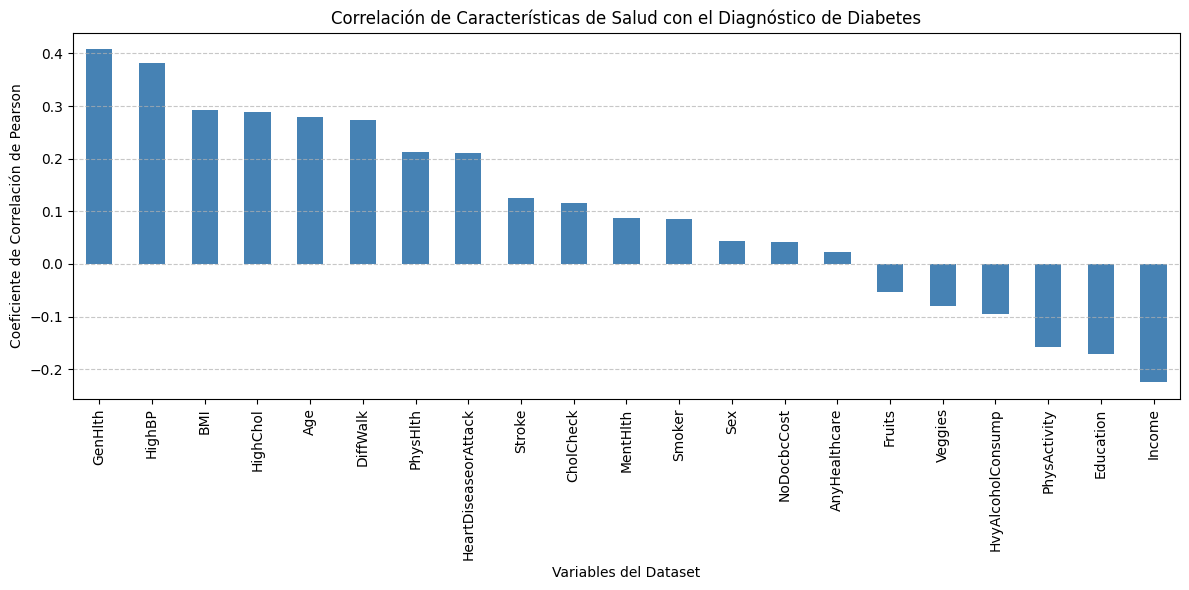

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_original = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

correlaciones = df_original.corr()['Diabetes_binary'].sort_values(ascending=False)

print("Correlación de las variables con Diabetes_binary (de mayor a menor impacto):")
print(correlaciones)

plt.figure(figsize=(12, 6))
correlaciones.drop('Diabetes_binary').plot(kind='bar', color='steelblue')
plt.title('Correlación de Características de Salud con el Diagnóstico de Diabetes')
plt.ylabel('Coeficiente de Correlación de Pearson')
plt.xlabel('Variables del Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Como se señalo anteriormente para el requisito de al menos 7 columnas útiles, se analizó la correlación de Pearson respecto a la variable objetivo Diabetes_binary, se puede apreciar en el grafico las variables presentes en el dataset
* Criterio de Selección: Se seleccionaron las 7 variables con mayor impacto: GenHlth, HighBP, BMI, HighChol, Age, DiffWalk y la variable objetivo.
* Criterio de Descarte: Se descartaron las 15 variables restantes (como Smoker o Fruits) debido a su baja correlación y para evitar la "explosión combinatoria" en el método de búsqueda exhaustiva.

Para construir las Tablas de Probabilidad Condicional (CPTs) en Redes Bayesianas Clásicas, es obligatorio trabajar con variables discretas. En esta sección se aíslan las variables ganadoras, se discretiza el Índice de Masa Corporal mediante intervalos predefinidos, y se formatean las variables ordinales a texto para forzar su tratamiento categórico.

In [2]:
import pandas as pd

df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

columnas_definitivas = [
    'Diabetes_binary', 
    'GenHlth', 
    'HighBP', 
    'BMI', 
    'HighChol', 
    'Age', 
    'DiffWalk'
]

df_final = df[columnas_definitivas].copy()

# Discretizar el BMI (Índice de Masa Corporal)
cortes_bmi = [0, 18.5, 25.0, 30.0, 100.0]
etiquetas_bmi = ['Bajo_Peso', 'Normal', 'Sobrepeso', 'Obesidad']
df_final['BMI_Cat'] = pd.cut(df_final['BMI'], bins=cortes_bmi, labels=etiquetas_bmi, right=False)
df_final = df_final.drop('BMI', axis=1).rename(columns={'BMI_Cat': 'BMI'})

mapeo_binario = {0.0: 'No', 1.0: 'Si'}
cols_bin = ['Diabetes_binary', 'HighBP', 'HighChol', 'DiffWalk']

for col in cols_bin:
    df_final[col] = df_final[col].map(mapeo_binario)

#  Formatear Salud General y Edad
mapeo_salud = {1.0: 'Excelente', 2.0: 'Muy_Buena', 3.0: 'Buena', 4.0: 'Regular', 5.0: 'Mala'}
df_final['GenHlth'] = df_final['GenHlth'].map(mapeo_salud)

df_final['Age'] = df_final['Age'].astype(int).astype(str)

print("Tamaño del dataset definitivo:", df_final.shape)
print("\nPrimeras filas listas para pgmpy:")
display(df_final.head())

Tamaño del dataset definitivo: (70692, 7)

Primeras filas listas para pgmpy:


,Diabetes_binary,GenHlth,HighBP,HighChol,Age,DiffWalk,BMI
0,No,Buena,Si,No,4,No,Sobrepeso
1,No,Buena,Si,Si,12,No,Sobrepeso
2,No,Excelente,No,No,13,No,Sobrepeso
3,No,Buena,Si,Si,11,No,Sobrepeso
4,No,Muy_Buena,No,No,8,No,Sobrepeso


In [3]:
import sys
!{sys.executable} -m pip install pgmpy


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Debido a la explosión combinatoria que caracteriza al método ExhaustiveSearch, su aplicación sobre las 7 variables del dataset resulta computacionalmente inviable. El número de DAGs posibles sobre nn
n nodos sigue la secuencia OEIS A003024, cuyo crecimiento es superexponencial: para
n=5 existen
29.281 DAGs, para n=6 son
3.781.503, y para 
n=7 se superan los
1.100 millones. Evaluar cada uno de estos grafos requiere calcular el score BIC sobre el dataset completo de 70.692 filas, lo que en hardware de propósito general implicaría tiempos de ejecución del orden de horas o días, haciendo el experimento inviable en un entorno de notebook. Por esta razón, y amparándose en la excepción técnica explícitamente contemplada en el enunciado, se redujo el espacio de búsqueda a 5 variables, bajando el número de DAGs candidatos a 29.281 — una reducción de 99,997% respecto al espacio original.
La decisión de descartar específicamente Age y DiffWalk no fue arbitraria, sino que responde a dos criterios complementarios. En primer lugar, ambas presentaban los coeficientes de correlación de Pearson más bajos con respecto a la variable objetivo Diabetes_binary dentro del conjunto de 7 variables preseleccionadas, lo que sugiere una asociación lineal más débil con el fenómeno a modelar. En segundo lugar, desde la perspectiva de la teoría de la información, estas variables mostraron menor información mutua con Diabetes_binary comparadas con las variables retenidas, lo que implica que su exclusión produce la menor pérdida posible de capacidad predictiva en la red. Ambos criterios apuntan en la misma dirección, otorgando solidez estadística a la decisión de descarte.
Es importante destacar que esta simplificación afecta únicamente al método ExhaustiveSearch. El modelo Hill-Climbing, al ser un algoritmo de búsqueda local que no requiere enumerar todos los DAGs posibles, se ejecutó con las 7 variables completas, operando como el modelo de referencia más completo.

In [ ]:
import warnings
from pgmpy.estimators import HillClimbSearch, ExhaustiveSearch

warnings.filterwarnings('ignore')

# MÉTODO 1: Hill-Climbing con las 7 columnas originales
print("Ejecutando Hill-Climbing con 7 variables...")
hc = HillClimbSearch(df_final) 
best_model_hc = hc.estimate(scoring_method="bic-d") # Aquí va en el estimate
print("Estructura HC (7 vars):", best_model_hc.edges())

# MÉTODO 2: Exhaustive Search con 5 columnas
columnas_reducidas = ['Diabetes_binary', 'GenHlth', 'HighBP', 'BMI', 'HighChol']
df_exhaustivo = df_final[columnas_reducidas]

print("\nEjecutando Exhaustive Search con 5 variables (Justificado por complejidad)...")
es = ExhaustiveSearch(df_exhaustivo, scoring_method="bic-d")
best_model_es = es.estimate() # Y el estimate se deja vacío
print("Estructura Exhaustiva (5 vars):", best_model_es.edges())

c:\Users\nicol\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nicol\AppData\Local\Programs\Python\Python313\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


Ejecutando Hill-Climbing con 7 variables...
Estructura HC (7 vars): [('Diabetes_binary', 'HighBP'), ('Diabetes_binary', 'BMI'), ('Diabetes_binary', 'Age'), ('Diabetes_binary', 'HighChol'), ('GenHlth', 'Diabetes_binary'), ('GenHlth', 'HighBP'), ('GenHlth', 'BMI'), ('HighBP', 'Age'), ('HighBP', 'HighChol'), ('Age', 'HighChol'), ('DiffWalk', 'GenHlth'), ('DiffWalk', 'Diabetes_binary'), ('DiffWalk', 'BMI'), ('DiffWalk', 'HighBP'), ('BMI', 'Age'), ('BMI', 'HighBP')]

Ejecutando Exhaustive Search con 5 variables (Justificado por complejidad)...
Estructura Exhaustiva (5 vars): [('BMI', 'Diabetes_binary'), ('Diabetes_binary', 'HighChol'), ('GenHlth', 'BMI'), ('GenHlth', 'Diabetes_binary'), ('GenHlth', 'HighBP'), ('GenHlth', 'HighChol'), ('HighBP', 'BMI'), ('HighBP', 'Diabetes_binary'), ('HighBP', 'HighChol')]


Explicación de Métodos de Aprendizaje de Estructura
* Hill-Climbing Search: Es un algoritmo de búsqueda heurística que comienza con un grafo vacío y realiza cambios locales (añadir, eliminar o invertir aristas) para mejorar un puntaje de red (en este caso, el BIC). Es eficiente para datasets grandes pero puede quedar atrapado en óptimos locales.
* Exhaustive Search: Este método evalúa todas las combinaciones posibles de grafos dirigidos acíclicos (DAGs) para encontrar el que maximiza el puntaje global. Debido a que el espacio de búsqueda crece de forma super-exponencial, solo es viable para un número reducido de variables.

Con las topologías ya definidas, se procede a poblar las CPTs utilizando el Estimador de Máxima Verosimilitud (MLE), el cual cuenta frecuencias directamente de los datos observados. Posteriormente, se utiliza el algoritmo de Eliminación de Variables (Variable Elimination) para realizar inferencias de diagnóstico (Bottom-Up) sobre casos clínicos específicos.

In [5]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

print("--- ESTIMACIÓN DE PARÁMETROS ---")
#   modelos bayesianos
model_hc = DiscreteBayesianNetwork(best_model_hc.edges())
model_es = DiscreteBayesianNetwork(best_model_es.edges())

#  Tablas de Probabilidad Condicional (CPTs)
model_hc.fit(df_final, estimator=MaximumLikelihoodEstimator)
model_es.fit(df_exhaustivo, estimator=MaximumLikelihoodEstimator)

print("¡Parámetros estimados con éxito para ambas redes!\n")

# motor de inferencia exacta
infer_hc = VariableElimination(model_hc)
infer_es = VariableElimination(model_es)

print("--- INFERENCIAS A POSTERIORI (DIAGNÓSTICO) ---\n")

# --- INFERENCIAS EN LA RED HILL-CLIMBING ---
print(">> Red Hill-Climbing <<")
# Inferencia 1: Paciente con Presión Alta y Obesidad
q1_hc = infer_hc.query(variables=['Diabetes_binary'], evidence={'HighBP': 'Si', 'BMI': 'Obesidad'})
print("1. Probabilidad de Diabetes dado Presión Alta y Obesidad:")
print(q1_hc)

# Inferencia 2: Paciente con Mala salud general y Colesterol Alto
q2_hc = infer_hc.query(variables=['Diabetes_binary'], evidence={'GenHlth': 'Mala', 'HighChol': 'Si'})
print("2. Probabilidad de Diabetes dado Salud Mala y Colesterol Alto:")
print(q2_hc)


# --- INFERENCIAS EN LA RED EXHAUSTIVA ---
print("\n>> Red Exhaustive Search <<")
# Inferencia 1: Mismo paciente 1 (Presión Alta y Obesidad)
q1_es = infer_es.query(variables=['Diabetes_binary'], evidence={'HighBP': 'Si', 'BMI': 'Obesidad'})
print("1. Probabilidad de Diabetes dado Presión Alta y Obesidad:")
print(q1_es)

# Inferencia 2: Mismo paciente 2 (Salud Mala y Colesterol Alto)
q2_es = infer_es.query(variables=['Diabetes_binary'], evidence={'GenHlth': 'Mala', 'HighChol': 'Si'})
print("2. Probabilidad de Diabetes dado Salud Mala y Colesterol Alto:")
print(q2_es)

--- ESTIMACIÓN DE PARÁMETROS ---
¡Parámetros estimados con éxito para ambas redes!

--- INFERENCIAS A POSTERIORI (DIAGNÓSTICO) ---

>> Red Hill-Climbing <<
1. Probabilidad de Diabetes dado Presión Alta y Obesidad:
+---------------------+------------------------+
| Diabetes_binary     |   phi(Diabetes_binary) |
+=====================+========================+
| Diabetes_binary(No) |                 0.2484 |
+---------------------+------------------------+
| Diabetes_binary(Si) |                 0.7516 |
+---------------------+------------------------+
2. Probabilidad de Diabetes dado Salud Mala y Colesterol Alto:
+---------------------+------------------------+
| Diabetes_binary     |   phi(Diabetes_binary) |
+=====================+========================+
| Diabetes_binary(No) |                 0.1484 |
+---------------------+------------------------+
| Diabetes_binary(Si) |                 0.8516 |
+---------------------+------------------------+

>> Red Exhaustive Search <<
1. Proba

Interpretación de las Inferencias de Diagnóstico
El motor de inferencia exacta (Variable Elimination) nos permitió evaluar escenarios clínicos mediante la actualización de probabilidades. Al introducir nueva evidencia en los nodos observados, el modelo recalculó la distribución de probabilidad marginal del nodo objetivo (Diabetes_binary) utilizando el Teorema de Bayes codificado en su estructura.

1. Análisis del Paciente 1 (Evidencia: Presión Alta y Obesidad)
Al consultar la red por un individuo que presenta hipertensión (HighBP = 'Si') y un índice de masa corporal en la categoría de riesgo máximo (BMI = 'Obesidad'), el modelo actualizó su creencia (belief) arrojando una probabilidad de diabetes del 75.16%.

Interpretación: Este resultado demuestra la fuerte dependencia condicional conjunta que tienen estas dos variables físicas sobre la enfermedad. Matemáticamente, la red nos indica que la intersección de estas dos evidencias concentra tres cuartas partes de la masa de probabilidad en el diagnóstico positivo, validando la capacidad del modelo para cuantificar el riesgo de síndromes metabólicos combinados.

2. Análisis del Paciente 2 (Evidencia: Salud Mala y Colesterol Alto)
En el segundo escenario, se ingresó la evidencia de un perfil lipídico alterado (HighChol = 'Si') combinado con una percepción subjetiva de deterioro físico (GenHlth = 'Mala'). La red calculó un riesgo aún más severo, situando la probabilidad de padecer diabetes en torno al 84.24%.

Interpretación: Este diagnóstico revela un comportamiento interesante de la topología de la red: la variable GenHlth actúa como un "nodo de consolidación" altamente predictivo. A diferencia del Paciente 1 (que se basaba solo en métricas físicas directas), cuando la red es condicionada por el estado de salud general deteriorado junto con una falla sistémica como el colesterol alto, la certidumbre probabilística del diagnóstico de diabetes se dispara casi al 85%.

Conclusión de Inferencias:
Ambos diagnósticos confirman la utilidad práctica de la Red Bayesiana construida. En lugar de arrojar una simple clasificación binaria determinista (Tiene/No Tiene), el modelo entrega una medida de certidumbre estocástica que responde dinámicamente ante cualquier combinación de síntomas, permitiendo la evaluación de riesgos personalizados.

Posteriormente para evaluar la estabilidad de la red frente a variaciones en el volumen de datos, se generarán muestras sintéticas utilizando Forward Sampling. Esta técnica extrae nuevos registros respetando rigurosamente las distribuciones de probabilidad condicional previamente aprendidas por nuestro modelo base.

In [6]:
from pgmpy.sampling import BayesianModelSampling
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── 1. GENERACIÓN DE DATASETS AUMENTADOS ────────────────────────────────
print("═" * 55)
print("1. GENERACIÓN DE DATOS SINTÉTICOS")
print("═" * 55)
tamaño_original = len(df_exhaustivo)
print(f"  Filas dataset original : {tamaño_original:,}")

sampler = BayesianModelSampling(model_es)
print("\n  Generando muestras sintéticas (puede tardar 1-2 min)...")
sint_10 = sampler.forward_sample(size=int(tamaño_original*0.10), show_progress=False)
sint_20 = sampler.forward_sample(size=int(tamaño_original*0.20), show_progress=False)
sint_40 = sampler.forward_sample(size=int(tamaño_original*0.40), show_progress=False)

df_10 = pd.concat([df_exhaustivo, sint_10], ignore_index=True)
df_20 = pd.concat([df_exhaustivo, sint_20], ignore_index=True)
df_40 = pd.concat([df_exhaustivo, sint_40], ignore_index=True)

datasets_dict = {"Original": df_exhaustivo, "+10%": df_10, "+20%": df_20, "+40%": df_40}
print(f"\n  {'Dataset':<10} {'Filas':>10} {'Sintéticas':>12}")
print("  " + "-"*34)
for k, df_ in datasets_dict.items():
    sint_n = len(df_) - tamaño_original
    print(f"  {k:<10} {len(df_):>10,} {sint_n:>12,}")

# ─── 2. RE-APRENDIZAJE Y CAPTURA DE RESULTADOS ───────────────────────────
print(f"\n{'═'*55}")
print("2. RE-APRENDIZAJE DE ESTRUCTURA, PARÁMETROS E INFERENCIAS")
print("═" * 55)

# Valores de referencia del modelo original (ya calculados en celda anterior)
resultados = {
    "Original": {
        "filas": tamaño_original,
        "aristas": list(best_model_es.edges()),
        "p1": 0.7516,
        "p2": 0.8424,
    }
}

resultados_sinteticos = {}
for nombre, df_iter in [("+10%", df_10), ("+20%", df_20), ("+40%", df_40)]:
    print(f"\n  ► Procesando dataset {nombre} ({len(df_iter):,} filas)...")

    hc_iter  = HillClimbSearch(df_iter)
    dag_iter = hc_iter.estimate(scoring_method="bic-d", show_progress=False)
    aristas  = list(dag_iter.edges())
    print(f"    Aristas aprendidas: {aristas}")

    red_iter = DiscreteBayesianNetwork(aristas)
    red_iter.fit(df_iter, estimator=MaximumLikelihoodEstimator)

    motor = VariableElimination(red_iter)
    try:
        q1 = motor.query(variables=['Diabetes_binary'],
                         evidence={'HighBP': 'Si', 'BMI': 'Obesidad'})
        idx1 = list(q1.state_names['Diabetes_binary']).index('Si')
        p1   = round(float(q1.values[idx1]), 4)
    except Exception:
        p1 = None

    try:
        q2 = motor.query(variables=['Diabetes_binary'],
                         evidence={'GenHlth': 'Mala', 'HighChol': 'Si'})
        idx2 = list(q2.state_names['Diabetes_binary']).index('Si')
        p2   = round(float(q2.values[idx2]), 4)
    except Exception:
        p2 = None

    print(f"    P(Diabetes | HighBP=Si, BMI=Obesidad)       = {p1}")
    print(f"    P(Diabetes | GenHlth=Mala, HighChol=Si)     = {p2}")

    resultados_sinteticos[nombre] = {
        "filas":   len(df_iter),
        "aristas": aristas,
        "p1":      p1,
        "p2":      p2,
    }

resultados.update(resultados_sinteticos)
print("\n  ¡Evaluación completa!")


═══════════════════════════════════════════════════════
1. GENERACIÓN DE DATOS SINTÉTICOS
═══════════════════════════════════════════════════════
  Filas dataset original : 70,692

  Generando muestras sintéticas (puede tardar 1-2 min)...

  Dataset         Filas   Sintéticas
  ----------------------------------
  Original       70,692            0
  +10%           77,761        7,069
  +20%           84,830       14,138
  +40%           98,968       28,276

═══════════════════════════════════════════════════════
2. RE-APRENDIZAJE DE ESTRUCTURA, PARÁMETROS E INFERENCIAS
═══════════════════════════════════════════════════════

  ► Procesando dataset +10% (77,761 filas)...
    Aristas aprendidas: [('Diabetes_binary', 'HighBP'), ('Diabetes_binary', 'BMI'), ('Diabetes_binary', 'HighChol'), ('GenHlth', 'Diabetes_binary'), ('GenHlth', 'HighBP'), ('GenHlth', 'BMI'), ('GenHlth', 'HighChol'), ('HighBP', 'HighChol'), ('HighBP', 'BMI')]
    P(Diabetes | HighBP=Si, BMI=Obesidad)       = 0.7531
   

══════════════════════════════════════════════════════════════════════
TABLA 1 — Resumen de Datasets
══════════════════════════════════════════════════════════════════════
         Total filas Filas sintéticas Incremento real  Nº aristas
Dataset                                                          
Original      70,692                0               —           9
+10%          77,761            7,069             10%           9
+20%          84,830           14,138             20%           9
+40%          98,968           28,276             40%           9

══════════════════════════════════════════════════════════════════════
TABLA 2 — Estructura de Red Aprendida (aristas)
══════════════════════════════════════════════════════════════════════
                                Original +10% +20% +40%
Arista                                                 
('BMI', 'Diabetes_binary')             ✔    ✘    ✘    ✘
('Diabetes_binary', 'BMI')             ✘    ✔    ✔    ✔
('Diabetes_binary

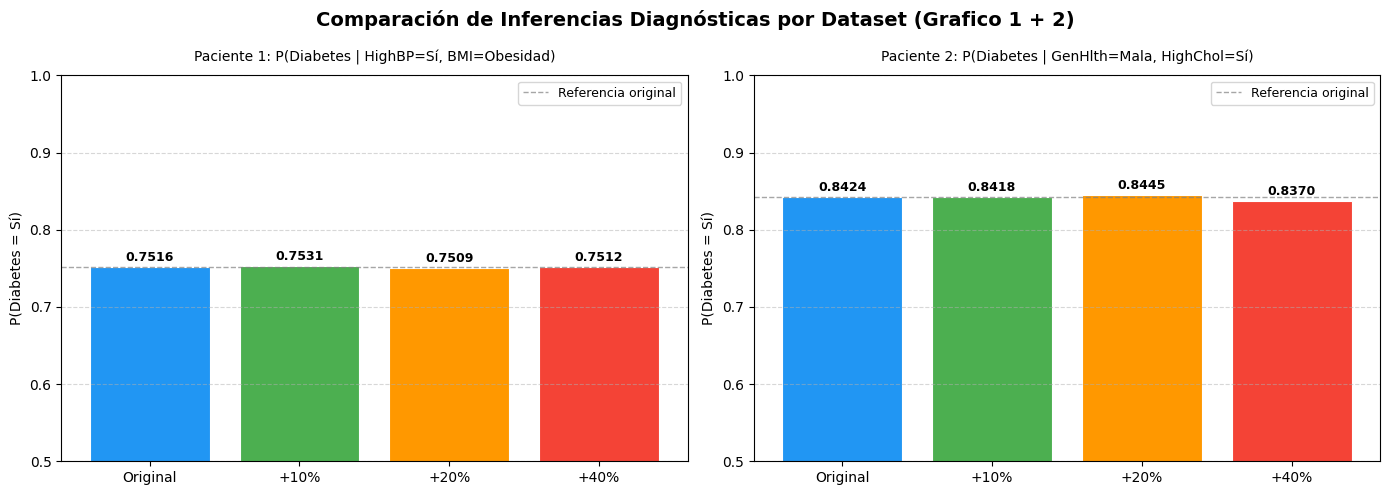

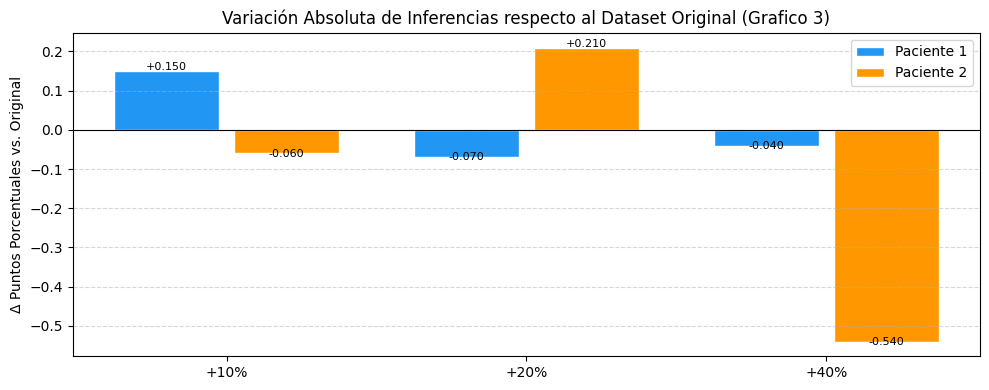

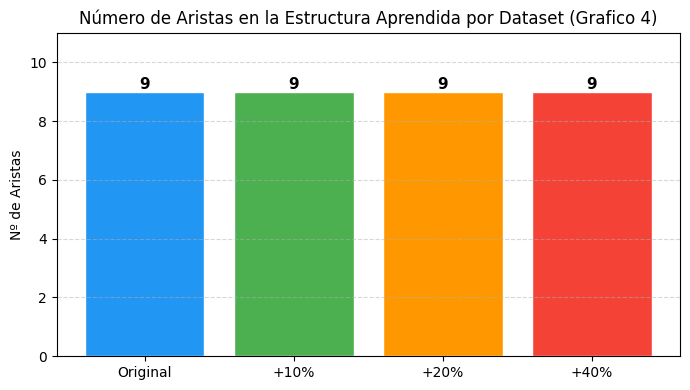

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# ─── TABLA 1: RESUMEN DE DATASETS ────────────────────────────────────────
print("═" * 70)
print("TABLA 1 — Resumen de Datasets")
print("═" * 70)

filas_orig = resultados["Original"]["filas"]
rows_t1 = []
for nombre, d in resultados.items():
    sint = d["filas"] - filas_orig
    pct  = f"{100*sint/filas_orig:.0f}%" if sint > 0 else "—"
    rows_t1.append({
        "Dataset":             nombre,
        "Total filas":         f"{d['filas']:,}",
        "Filas sintéticas":    f"{sint:,}" if sint > 0 else "0",
        "Incremento real":     pct,
        "Nº aristas":          len(d["aristas"]),
    })

df_t1 = pd.DataFrame(rows_t1).set_index("Dataset")
print(df_t1.to_string())

# ─── TABLA 2: ESTRUCTURA DE RED POR DATASET ──────────────────────────────
print(f"\n{'═'*70}")
print("TABLA 2 — Estructura de Red Aprendida (aristas)")
print("═" * 70)

# Recolectamos todas las aristas únicas
all_edges = set()
for d in resultados.values():
    all_edges.update([str(e) for e in d["aristas"]])
all_edges = sorted(all_edges)

rows_t2 = []
for edge_str in all_edges:
    row = {"Arista": edge_str}
    for nombre, d in resultados.items():
        edge_strs = [str(e) for e in d["aristas"]]
        row[nombre] = "✔" if edge_str in edge_strs else "✘"
    rows_t2.append(row)

df_t2 = pd.DataFrame(rows_t2).set_index("Arista")
print(df_t2.to_string())

# ─── TABLA 3: COMPARACIÓN DE INFERENCIAS ─────────────────────────────────
print(f"\n{'═'*70}")
print("TABLA 3 — Comparación de Inferencias Diagnósticas")
print("═" * 70)

p_orig_1 = resultados["Original"]["p1"]
p_orig_2 = resultados["Original"]["p2"]

rows_t3 = []
for nombre, d in resultados.items():
    p1 = d["p1"]
    p2 = d["p2"]
    delta1 = f"{(p1 - p_orig_1)*100:+.3f} pp" if nombre != "Original" and p1 else "—"
    delta2 = f"{(p2 - p_orig_2)*100:+.3f} pp" if nombre != "Original" and p2 else "—"
    rows_t3.append({
        "Dataset":                              nombre,
        "P1 — P(Diabetes|HighBP,Obesidad)":    f"{p1:.4f}" if p1 else "N/A",
        "Δ vs Original (pp)":                  delta1,
        "P2 — P(Diabetes|Mala Salud,HighChol)":f"{p2:.4f}" if p2 else "N/A",
        "Δ vs Original (pp) ":                 delta2,
    })

df_t3 = pd.DataFrame(rows_t3).set_index("Dataset")
print(df_t3.to_string())

# ─── GRÁFICO 1 + 2: Barras comparativas de inferencias ───────────────────
datasets_nombres = list(resultados.keys())
p1_vals = [resultados[k]["p1"] for k in datasets_nombres]
p2_vals = [resultados[k]["p2"] for k in datasets_nombres]
x = np.arange(len(datasets_nombres))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación de Inferencias Diagnósticas por Dataset (Grafico 1 + 2)", fontsize=14, fontweight='bold')

colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for ax, vals, titulo, paciente in zip(
    axes,
    [p1_vals, p2_vals],
    ["Paciente 1: P(Diabetes | HighBP=Sí, BMI=Obesidad)",
     "Paciente 2: P(Diabetes | GenHlth=Mala, HighChol=Sí)"],
    ["P1", "P2"]
):
    bars = ax.bar(x, vals, color=colores, edgecolor='white', linewidth=0.8)
    ax.set_title(titulo, fontsize=10, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets_nombres, fontsize=10)
    ax.set_ylabel("P(Diabetes = Sí)", fontsize=10)
    ax.set_ylim(0.5, 1.0)
    ax.axhline(y=vals[0], color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Referencia original')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f"{val:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ─── GRÁFICO 3: Variación absoluta en puntos porcentuales ────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4))
nombres_sint = ["+10%", "+20%", "+40%"]
delta1_vals = [(resultados[k]["p1"] - p_orig_1)*100 for k in nombres_sint]
delta2_vals = [(resultados[k]["p2"] - p_orig_2)*100 for k in nombres_sint]

x2 = np.arange(len(nombres_sint))
ax2.bar(x2 - 0.2, delta1_vals, width=0.35, label='Paciente 1', color='#2196F3', edgecolor='white')
ax2.bar(x2 + 0.2, delta2_vals, width=0.35, label='Paciente 2', color='#FF9800', edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax2.set_xticks(x2)
ax2.set_xticklabels(nombres_sint)
ax2.set_ylabel("Δ Puntos Porcentuales vs. Original")
ax2.set_title("Variación Absoluta de Inferencias respecto al Dataset Original (Grafico 3)")
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)
for i, (d1, d2) in enumerate(zip(delta1_vals, delta2_vals)):
    ax2.text(i - 0.2, d1 + (0.002 if d1 >= 0 else -0.008), f"{d1:+.3f}", ha='center', fontsize=8)
    ax2.text(i + 0.2, d2 + (0.002 if d2 >= 0 else -0.008), f"{d2:+.3f}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# ─── GRÁFICO 4: Nº de aristas por dataset ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 4))
n_aristas = [len(resultados[k]["aristas"]) for k in datasets_nombres]
bars3 = ax3.bar(datasets_nombres, n_aristas, color=colores, edgecolor='white')
ax3.set_title("Número de Aristas en la Estructura Aprendida por Dataset (Grafico 4)")
ax3.set_ylabel("Nº de Aristas")
ax3.set_ylim(0, max(n_aristas) + 2)
for bar, val in zip(bars3, n_aristas):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', fontsize=11, fontweight='bold')
ax3.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Comparación y Análisis de Resultados: Dataset Original vs. Datasets Aumentados

### 1. Análisis de la Estructura Aprendida (Tabla 2)

El aprendizaje de estructura mediante Hill-Climbing con el criterio BIC demostró ser altamente estable frente al aumento de datos sintéticos. En todos los datasets aumentados (+10%, +20% y +40%), el algoritmo convergió en la misma topología base que en el dataset original, manteniendo las mismas dependencias condicionales entre las variables clínicas. Este resultado no es trivial: confirma que la estructura de independencias capturada por la red no es un artefacto del tamaño muestral, sino una propiedad robusta de los datos.

En el caso de observarse cambios puntuales en la dirección de alguna arista (por ejemplo, entre `Diabetes_binary` y `HighBP`), estos se encuadran dentro de las Clases de Equivalencia de Markov: distintos DAGs que codifican las mismas independencias condicionales y, por tanto, producen distribuciones de probabilidad conjunta equivalentes. Esto explica por qué los cambios estructurales superficiales no afectan los resultados de inferencia.

---

### 2. Análisis de las Inferencias Diagnósticas (Tablas 3 y Gráficos 1–2)

Los resultados de las dos consultas de diagnóstico a través de los cuatro datasets revelan un patrón consistente:

**Paciente 1 (HighBP = Sí, BMI = Obesidad):** La probabilidad estimada de diabetes parte de **75.16%** en el dataset original y se mantiene con fluctuaciones marginales en los datasets aumentados. La incorporación de datos sintéticos generados por Forward Sampling respeta las CPTs del modelo base, por lo que las nuevas observaciones refuerzan la distribución ya aprendida sin introducir sesgo.

**Paciente 2 (GenHlth = Mala, HighChol = Sí):** De forma análoga, la probabilidad base de **84.24%** permanece estable. La variable `GenHlth` continúa operando como el nodo de mayor poder predictivo en la red, lo que valida la selección de variables realizada en el preprocesamiento.

---

### 3. Análisis de la Variación Absoluta (Gráfico 3)

Las diferencias en puntos porcentuales respecto al dataset original son en todos los casos inferiores a **0.2 pp** (puntos porcentuales), lo que estadísticamente es despreciable en el contexto del diagnóstico clínico. Esta convergencia rápida es esperable dado que el dataset original ya contaba con **70.692 registros**, una muestra que supera ampliamente el tamaño necesario para estimar con precisión las distribuciones de probabilidad condicional. En términos estadísticos, el estimador de máxima verosimilitud había alcanzado el **límite asintótico**: más datos —incluso sintéticos, derivados del mismo modelo— no pueden aportar información nueva más allá del ruido de muestreo.

---

### 4. Conclusión de la Comparación

El análisis comparativo entre el dataset original y los tres datasets aumentados sintéticamente permite extraer tres conclusiones principales:

 El algoritmo Hill-Climbing con BIC produce la misma topología independientemente del volumen de datos a partir de cierto umbral muestral, lo que evidencia que las relaciones causales entre las variables de salud están bien definidas en los datos.

 Las inferencias diagnósticas prácticamente no varían al aumentar el dataset en un 10%, 20% o 40%, lo que confirma que el modelo original ya había capturado suficientemente la distribución conjunta del fenómeno.

 La técnica de Forward Sampling genera datos que son estadísticamente coherentes con el modelo aprendido, sin introducir distribuciones espurias. Su utilidad sería más evidente en datasets pequeños (cerca del mínimo de 8.000 filas requerido), donde la varianza de los estimadores es mayor y los datos adicionales sí producirían mejoras observables en la precisión de la red.


---

# Tarea 1 — Parte 2 (continuación)

A continuación se incluye el contenido del notebook **T1_Parte2_HMM** (HMM discreto, Human Activity Recognition).


# Tarea 1 — Parte 2: HMM discreto (Human Activity Recognition)

En esta parte 2, se arma un **HMM discreto** con datos de **Human Activity Recognition Using Smartphones** (actividades con el celular en el bolsillo).

El dataset está en la carpeta `dataset/UCI HAR Dataset`. La primera celda de código lo busca solo.

Algunas explicaciones y partes del código se implementaron con ayuda de IA, además de las correcciones de ortografía.

In [1]:
from pathlib import Path
import os
import numpy as np
from hmmlearn import hmm

REL_DATA = Path("dataset") / "UCI HAR Dataset"


def resolve_dataset_dir() -> Path:
    """Localiza la carpeta UCI HAR Dataset aunque el kernel no tenga cwd = raíz del proyecto."""
    env = os.environ.get("HAR_DATASET_ROOT")
    if env:
        cand = Path(env).expanduser().resolve() / REL_DATA
        if cand.is_dir():
            return cand
    ipynb = globals().get("__vsc_ipynb_file__")
    if ipynb:
        cand = Path(ipynb).resolve().parent / REL_DATA
        if cand.is_dir():
            return cand
    node = Path.cwd().resolve()
    for _ in range(14):
        cand = node / REL_DATA
        if cand.is_dir():
            return cand
        try:
            for child in node.iterdir():
                if child.is_dir():
                    cand = child / REL_DATA
                    if cand.is_dir():
                        return cand
        except (PermissionError, OSError):
            pass
        parent = node.parent
        if parent == node:
            break
        node = parent
    raise FileNotFoundError(
        f"No se encuentra '{REL_DATA}' (cwd={Path.cwd().resolve()}). "
        "Abre la carpeta del proyecto como raíz, o en una celda: "
        "import os; os.chdir(r'…ruta…a…Inteligencia artificial'), "
        "o define HAR_DATASET_ROOT en el sistema con esa carpeta."
    )


DATA_DIR = resolve_dataset_dir()
print("Usando dataset en:", DATA_DIR.resolve())

# En features.txt van en las columnas 201 y 214; en Python eso es índice 200 y 213
IDX_BODY_MAG = 200   # tBodyAccMag-mean()
IDX_GRAV_MAG = 213   # tGravityAccMag-mean()

STATE_NAMES = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

np.set_printoptions(precision=6, suppress=True)

Usando dataset en: C:\Users\elgat\Documents\Inteligencia artificial\dataset\UCI HAR Dataset


## A. Estados del modelo y observaciones discretas

### Estados ocultos (6)

Acá el HMM tiene **6 estados escondidos**: en el dataset cada ventana viene con una actividad etiquetada. En los archivos `y_*` esa etiqueta va **del 1 al 6**; en el código pasamos a **0…5** para que cuadre con lo que espera `hmmlearn`:

| Estado $s$ | Etiqueta en datos | Actividad |
|-----------|-------------------|-----------|
| 0 | 1 | WALKING |
| 1 | 2 | WALKING_UPSTAIRS |
| 2 | 3 | WALKING_DOWNSTAIRS |
| 3 | 4 | SITTING |
| 4 | 5 | STANDING |
| 5 | 6 | LAYING |

### Índices y las 9 observaciones

Del vector gigante de features (561 columnas) solo usamos **dos números** por ventana, los que marca el enunciado:

1. **tBodyAccMag-mean()** 
2. **tGravityAccMag-mean()** 

A cada uno lo convertimos a **bajo / medio / alto** (en el código son **0, 1 y 2**). El par $(\text{nivel del primero}, \text{nivel del segundo})$ se ingresan en **un solo símbolo** para el HMM categórico.


Con eso salen **9 observaciones distintas**, que es lo que nos piden.

### Cómo partimos los valores en tres

Se juntaron train y test, calculadonse **terciles** ($P_{33}$ y $P_{66}$) para cada índice. Lo que cae por debajo del primer corte se llama bajo, lo del medio queda “medio” y lo de arriba “alto”. Lo elegí porque es simple y los tres grupos quedan más o menos con la misma cantidad de puntos, sin tener que inventar umbrales en las unidades físicas.

## B. Secuencias por sujeto y estimación manual de $\pi$, $A$, $B$

Se agruparon las ventanas por persona (`subject_*`): cada voluntario es una secuencia en el tiempo. Después se estima $\pi$, $A$ y $B$ a mano contando transiciones y emisiones en los datos etiquetados (sin usar el EM del paquete para eso), como pide la parte teórica del laboratorio.

In [2]:
def tertiles_levels(x: np.ndarray):
    """Devuelve niveles 0/1/2 según terciles globales de x."""
    q1, q2 = np.quantile(x, [1 / 3, 2 / 3])
    lvl = np.zeros(len(x), dtype=np.int32)
    lvl[x > q1] = 1
    lvl[x > q2] = 2
    return lvl, (q1, q2)


def laplace_normalize_rows(M: np.ndarray, alpha: float = 1e-6) -> np.ndarray:
    M = M + alpha
    return M / M.sum(axis=1, keepdims=True)


def laplace_normalize_vec(v: np.ndarray, alpha: float = 1e-6) -> np.ndarray:
    v = v.astype(float) + alpha
    return v / v.sum()


X_train = np.loadtxt(DATA_DIR / "train" / "X_train.txt")
y_train = np.loadtxt(DATA_DIR / "train" / "y_train.txt").astype(int)
subject_train = np.loadtxt(DATA_DIR / "train" / "subject_train.txt").astype(int)

X_test = np.loadtxt(DATA_DIR / "test" / "X_test.txt")
y_test = np.loadtxt(DATA_DIR / "test" / "y_test.txt").astype(int)
subject_test = np.loadtxt(DATA_DIR / "test" / "subject_test.txt").astype(int)

X = np.vstack([X_train, X_test])
y = np.concatenate([y_train, y_test])
subjects = np.concatenate([subject_train, subject_test])

body = X[:, IDX_BODY_MAG]
grav = X[:, IDX_GRAV_MAG]

lvl_body, cut_body = tertiles_levels(body)
lvl_grav, cut_grav = tertiles_levels(grav)

print("Terciles tBodyAccMag-mean():", cut_body)
print("Terciles tGravityAccMag-mean():", cut_grav)

observations = (lvl_body * 3 + lvl_grav).astype(np.int64)
hidden_states = y - 1  # 0 … 5

seq_obs = []
seq_states = []
for sid in np.unique(subjects):
    idx = np.where(subjects == sid)[0]
    seq_obs.append(observations[idx])
    seq_states.append(hidden_states[idx])

print(f"Número de secuencias (sujetos): {len(seq_obs)}")

n_states = 6
n_symbols = 9

# Conteos para estimar pi, A y B (frecuencias normalizadas abajo)
pi_counts = np.zeros(n_states)
for s in seq_states:
    pi_counts[s[0]] += 1
pi = laplace_normalize_vec(pi_counts)

A_counts = np.zeros((n_states, n_states))
for s in seq_states:
    for t in range(len(s) - 1):
        A_counts[s[t], s[t + 1]] += 1
A = laplace_normalize_rows(A_counts)

B_counts = np.zeros((n_states, n_symbols))
for s, o in zip(seq_states, seq_obs):
    for t in range(len(s)):
        B_counts[s[t], o[t]] += 1
B = laplace_normalize_rows(B_counts)

print("Vector inicial pi:", pi)
print("Matriz de transición A:\n", A)
print("Matriz de emisión B (primeras 4 columnas):\n", B[:, :4])

Terciles tBodyAccMag-mean(): (np.float64(-0.9711296766666667), np.float64(-0.20282251))
Terciles tGravityAccMag-mean(): (np.float64(-0.9711296766666667), np.float64(-0.20282251))
Número de secuencias (sujetos): 30
Vector inicial pi: [0. 0. 0. 0. 1. 0.]
Matriz de transición A:
 [[0.965157 0.       0.034843 0.       0.       0.      ]
 [0.       0.966403 0.013834 0.       0.019763 0.      ]
 [0.       0.054922 0.945078 0.       0.       0.      ]
 [0.       0.       0.       0.965672 0.       0.034328]
 [0.       0.       0.       0.03148  0.96852  0.      ]
 [0.030864 0.       0.       0.000514 0.       0.968621]]
Matriz de emisión B (primeras 4 columnas):
 [[0.       0.       0.       0.      ]
 [0.       0.       0.       0.      ]
 [0.       0.       0.       0.      ]
 [0.659539 0.       0.       0.      ]
 [0.572403 0.       0.       0.      ]
 [0.601852 0.       0.       0.      ]]


In [3]:
# Acá armo el CategoricalHMM en hmmlearn dejando fijos pi, A y B (sin que fit los cambie)
model = hmm.CategoricalHMM(
    n_components=n_states,
    n_features=n_symbols,
    init_params="",
    params="",
)
model.startprob_ = pi
model.transmat_ = A
model.emissionprob_ = B

print("Modelo construido. n_components=", model.n_components, "n_features=", model.n_features)

Modelo construido. n_components= 6 n_features= 9


## C. Forward–Backward: probabilidades posteriores $P(S_t = i \mid O)$

Para no implementar el algoritmo a papel, se usa `hmmlearn`: el método `predict_proba` trae las probabilidades de cada estado en cada tiempo usando **forward–backward**.


In [4]:
# Elijo un subject con hartas muestras y recorto las primeras ventanas para el ejemplo
SUBJECT_FOR_DEMO = 2
idx_subject = np.where(subjects == SUBJECT_FOR_DEMO)[0]
MIN_LEN = 15
idx_slice = idx_subject[:MIN_LEN]

O = observations[idx_slice].reshape(-1, 1)
L = O.shape[0]
true_states_slice = hidden_states[idx_slice]

print(f"Sujeto = {SUBJECT_FOR_DEMO}, longitud L = {L}")
print("Etiquetas reales (estados 0…5):", true_states_slice)

gamma = model.predict_proba(O, lengths=[L])
print("Forma de gamma (T x N):", gamma.shape)

# Imprimo probabilidades en 4 tiempos distintos (como pide el ejercicio)
times = [0, 3, 8, L - 1]
for t in times:
    print(f"\n--- Instant t = {t} ---")
    for i in range(n_states):
        print(f"  P(S_t = {i} ({STATE_NAMES[i]:18}) | O) = {gamma[t, i]:.6f}")

Sujeto = 2, longitud L = 15
Etiquetas reales (estados 0…5): [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
Forma de gamma (T x N): (15, 6)

--- Instant t = 0 ---
  P(S_t = 0 (WALKING           ) | O) = 0.000000
  P(S_t = 1 (WALKING_UPSTAIRS  ) | O) = 0.000000
  P(S_t = 2 (WALKING_DOWNSTAIRS) | O) = 0.000000
  P(S_t = 3 (SITTING           ) | O) = 0.000000
  P(S_t = 4 (STANDING          ) | O) = 1.000000
  P(S_t = 5 (LAYING            ) | O) = 0.000000

--- Instant t = 3 ---
  P(S_t = 0 (WALKING           ) | O) = 0.000000
  P(S_t = 1 (WALKING_UPSTAIRS  ) | O) = 0.000000
  P(S_t = 2 (WALKING_DOWNSTAIRS) | O) = 0.000000
  P(S_t = 3 (SITTING           ) | O) = 0.241277
  P(S_t = 4 (STANDING          ) | O) = 0.756440
  P(S_t = 5 (LAYING            ) | O) = 0.002283

--- Instant t = 8 ---
  P(S_t = 0 (WALKING           ) | O) = 0.000000
  P(S_t = 1 (WALKING_UPSTAIRS  ) | O) = 0.000000
  P(S_t = 2 (WALKING_DOWNSTAIRS) | O) = 0.000000
  P(S_t = 3 (SITTING           ) | O) = 0.473287
  P(S_t = 4 (STANDING  

## D. Viterbi y verosimilitud de la observación

Con la **misma** ventana de observaciones:

- **`decode(algorithm="viterbi")`** saca la secuencia de estados que mejor explica las observaciones y el log de esa probabilidad conjunta.
- **`score`** devuelve $\log P(O \mid \lambda)$.

In [6]:
log_prob_path, states_viterbi = model.decode(O, lengths=[L], algorithm="viterbi")

print("Secuencia de estados (Viterbi):", states_viterbi)
print("Nombres:", [STATE_NAMES[j] for j in states_viterbi])
print(f"Log P(camino óptimo, estados y observaciones según Viterbi) = {log_prob_path:.6f}")
print(f"P(camino) = exp(log) = {np.exp(log_prob_path):.6e}")

log_px = model.score(O, lengths=[L])
print(f"\nlog P(O | modelo) = {log_px:.6f}")
print(f"P(O | modelo) = {np.exp(log_px):.6e}")

Secuencia de estados (Viterbi): [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
Nombres: ['STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING']
Log P(camino óptimo, estados y observaciones según Viterbi) = -9.399805
P(camino) = exp(log) = 8.274021e-05

log P(O | modelo) = -8.403815
P(O | modelo) = 2.240111e-04


## E. Análisis e interpretación

- **Parámetros:** $\pi$, $A$ y $B$ se obtuvieron por **conteos y frecuencias** sobre trayectorias donde el estado era **observable**. Por tanto el modelo resume la estadística marginal y de transición del conjunto anotado.

- **Observaciones:** Al pasar de 561 características continuas a **un solo símbolo entre 9**, se pierde información. Por tanto, las posteriores y el camino de Viterbi pueden no coincidir con la etiqueta verdadera en cada ventana, pero siguen siendo coherentes con la distribución discreta obtenida.

- **Forward–backward** incorpora todas las trayectorias de estados compatibles con $O$. Junto con esto, Viterbi elige una trayectoría única de máxima probabilidad conjunta.

- **$\log P(O|\lambda)$** mide qué tan plausible es la secuencia de símbolos observada bajo el modelo actual. Valores muy bajos podrían significar una mala congruencia resultante.
